In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [4]:
import pandas as pd
from src.utils import prepare_data, plot_time_series
from src.utils import inspect_data, plot_numeric_distributions, plot_boxplots
from src.utils import load_clean_inspect, plot_missingness, plot_corr_heatmap, plot_timeseries, persistence_mae
import torch.nn as nn
import numpy as np
import torch
import kagglehub
import os


Shape: (1515, 7)

Columns:
['timestamp', 'GBP_USD', 'GBP_EUR', 'GBP_JPY', 'GBP_KRW', 'GBP_CHF', 'target']

Data types:
timestamp    datetime64[us]
GBP_USD             float64
GBP_EUR             float64
GBP_JPY             float64
GBP_KRW             float64
GBP_CHF             float64
target              float64
dtype: object

First 5 rows:
   timestamp  GBP_USD  GBP_EUR   GBP_JPY    GBP_KRW  GBP_CHF  target
0 2020-02-28   1.2776   1.1630  137.9169  1544.9761   1.2371  8.9312
1 2020-03-02   1.2748   1.1454  137.5764  1520.2118   1.2234  8.8720
2 2020-03-03   1.2819   1.1465  137.8683  1522.1922   1.2250  8.9193
3 2020-03-04   1.2821   1.1511  137.5437  1518.9295   1.2252  8.8778
4 2020-03-05   1.2922   1.1550  137.8777  1536.0123   1.2285  8.9635

Missing values per column:
timestamp    0
GBP_USD      0
GBP_EUR      0
GBP_JPY      0
GBP_KRW      0
GBP_CHF      0
target       0
dtype: int64

Missing value percentages:
timestamp    0.0
GBP_USD      0.0
GBP_EUR      0.0
GBP_JPY      0.0


/Users/apple/COMP0197-group-project/src/utils.py:115: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_wide["timestamp"] = pd.to_datetime(df_wide[timestamp_col], errors="coerce")


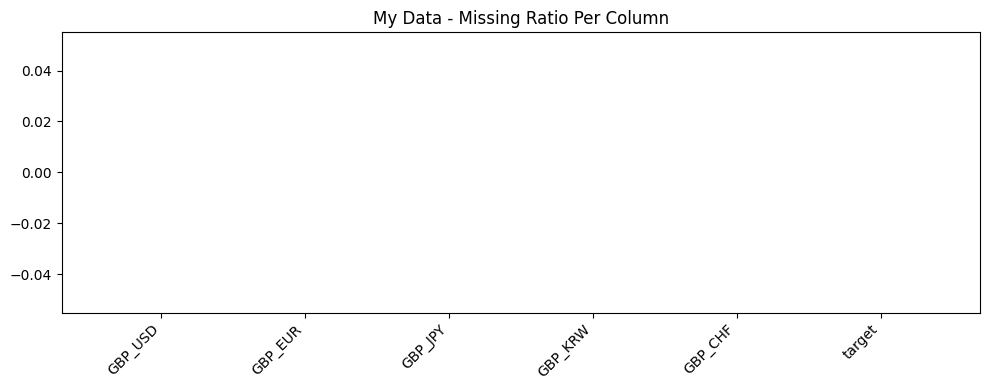

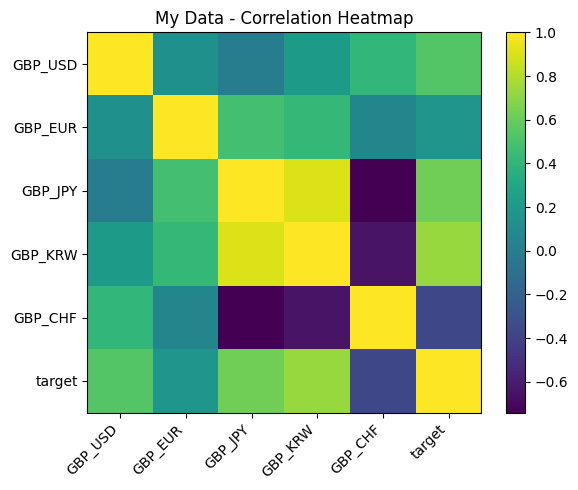

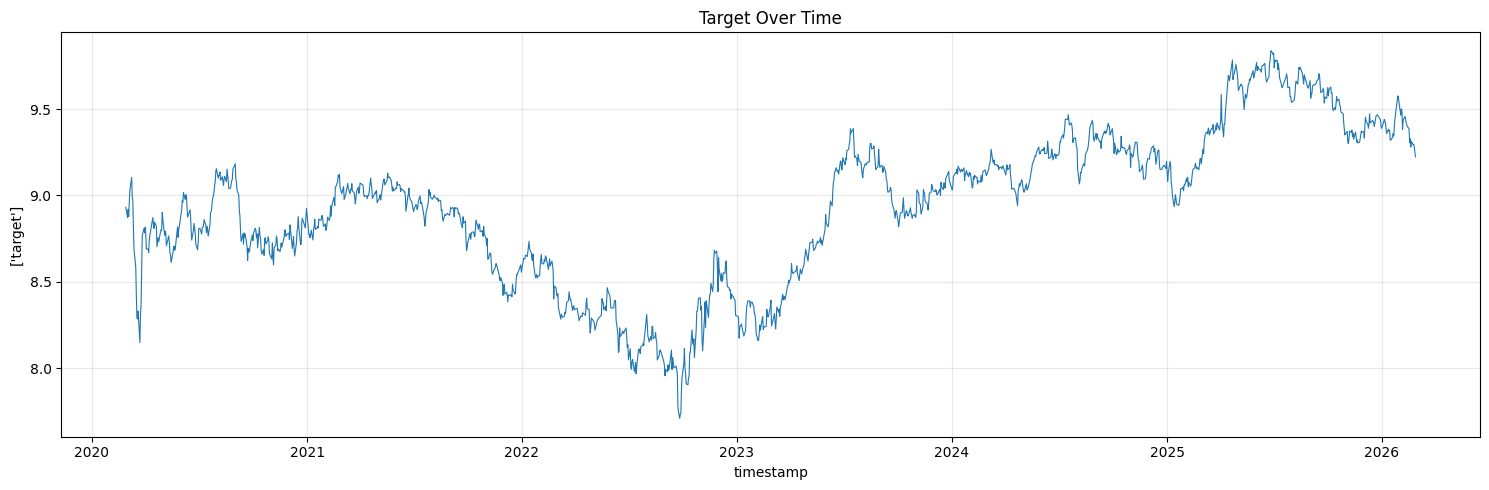

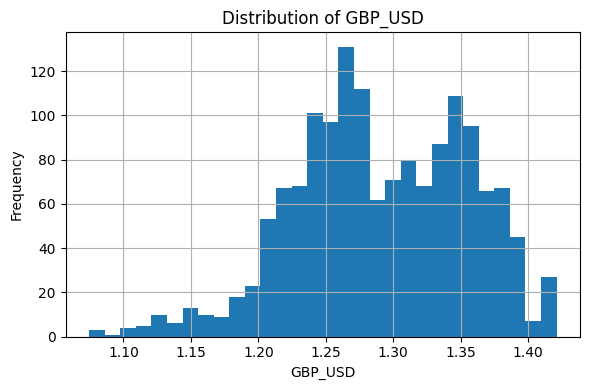

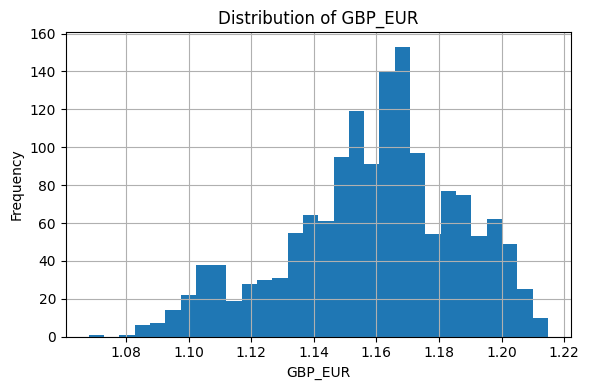

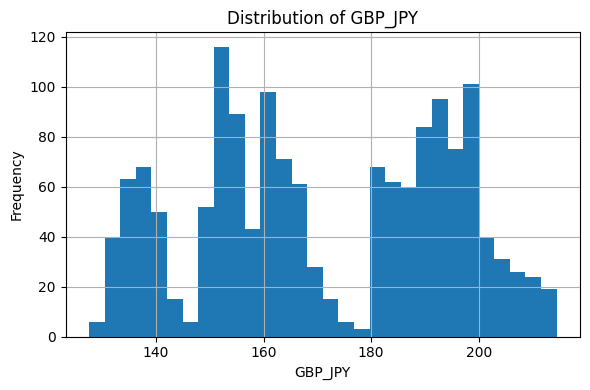

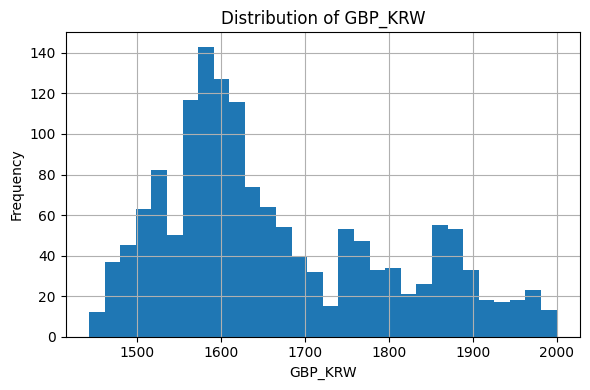

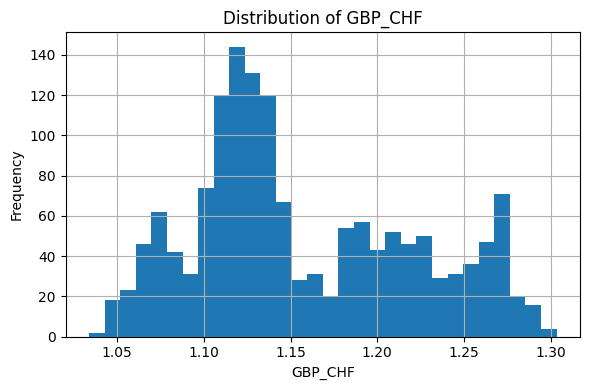

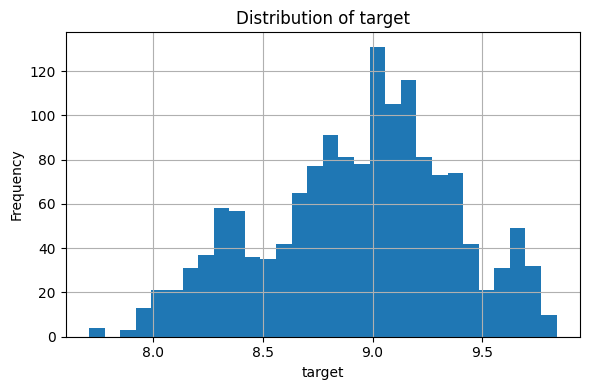

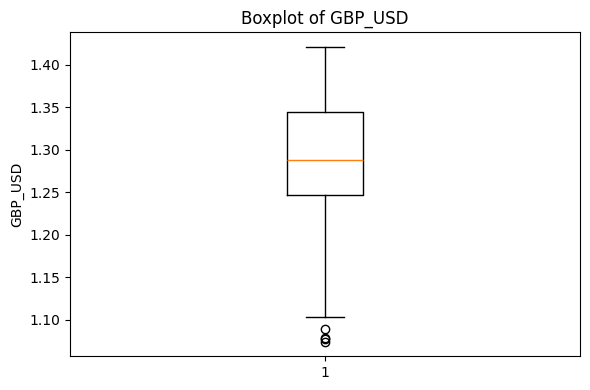

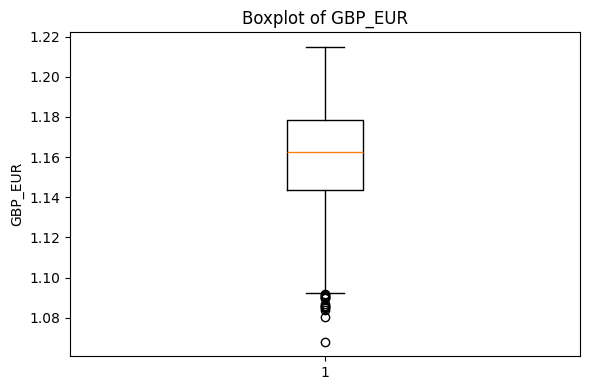

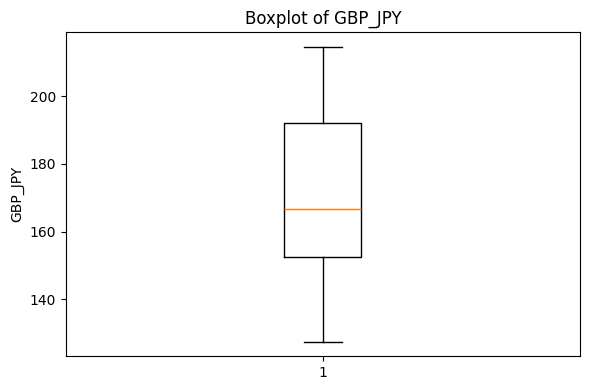

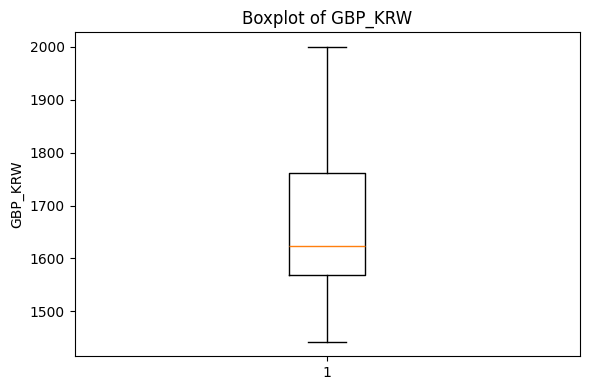

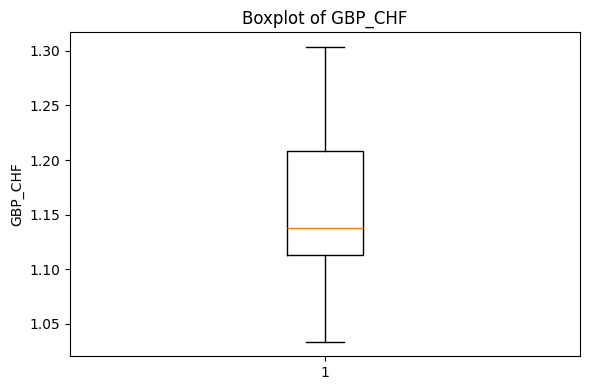

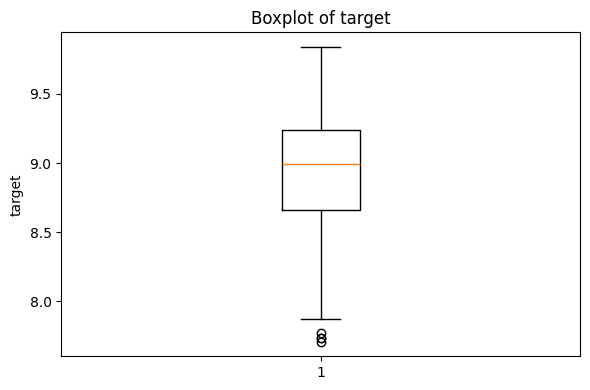

Persistence baseline MAE: 0.03320079260237779


In [17]:
# 1. Load + inspect + clean
timestamp_col = "timestamp"

df, target_col = load_clean_inspect(
    path_or_url="../data/raw/GBP_FX_BoE_daily.csv",
    timestamp_col=timestamp_col,
    target_col=None,   # defaults to last numeric column
    fill_method="interpolate"
)

# 2. Visual checks
plot_missingness(df, timestamp_col=timestamp_col, title="My Data")
plot_corr_heatmap(df, timestamp_col=timestamp_col, title="My Data")
plot_time_series(df, timestamp_col=timestamp_col, col=[target_col], title="Target Over Time")
plot_numeric_distributions(df)
plot_boxplots(df)

# 3. Prepare sequences for LSTM
feature_cols = [c for c in df.columns if c != "timestamp"]
train_loader, test_loader, scaler = prepare_data(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    seq_length=14,
    train_split=0.8,
    batch_size=64
)

# 4. Baseline
baseline_mae = persistence_mae(df[target_col].values)
print("Persistence baseline MAE:", baseline_mae)

In [6]:


# # --- 1. CONFIGURATION ---
# TARGET = 'target'
# FEATURES = ["GBP_USD","GBP_EUR","GBP_JPY","GBP_KRW","GBP_CHF"]
# SEQ_LEN = 14


# # Load Data
# # path = kagglehub.dataset_download("saurabhshahane/electricity-load-forecasting")

# # print("Path to dataset files:", path)
# # data_file = os.path.join(path, "acorn_details.csv")
# # df = pd.read_csv(data_file)


# URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
# df = pd.read_csv(URL, compression='zip')[5::6] # Hourly



In [7]:
# EDA

# df = inspect_data(df, datetime_col="tstp")

# plot_numeric_distributions(df)
# plot_boxplots(df)

# plot_time_series(df, target_col)


In [8]:

# # --- 3. PREPARE DATA ---
# train_loader, test_loader, scaler = prepare_data(
#     df, 
#     target_col=TARGET, 
#     feature_cols=FEATURES, 
#     seq_length=SEQ_LEN
# )

In [9]:
class DeterministicLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1, dropout=0.2):
        super(DeterministicLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_dim, 
            hidden_dim, 
            num_layers, 
            batch_first=True,
            dropout=dropout)
        
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        return self.fc(last_time_step)

# Initialize
model = DeterministicLSTM(input_dim=len(feature_cols), hidden_dim=64, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss() # Standard deterministic loss

NameError: name 'feature_cols' is not defined

In [10]:
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 10
BATCH_SIZE = 64


# Model, Optimizer, Criterion
model = DeterministicLSTM(input_dim=len(feature_cols), hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss() 

# # Training Loop
# train_losses = []
# for epoch in range(EPOCHS):
#     model.train()
#     batch_losses = []
#     for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
#         optimizer.zero_grad()
#         output = model(batch_x).squeeze()
#         loss = criterion(output, batch_y)
#         loss.backward()
#         optimizer.step()
#         batch_losses.append(loss.item())
    
#     avg_loss = np.mean(batch_losses)
#     train_losses.append(avg_loss)
#     print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

NameError: name 'feature_cols' is not defined

In [11]:
import numpy as np
import torch
from tqdm import tqdm

def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    device="cpu",
    save_path="best_model.pt",
    early_stopping_patience=5
):
    model.to(device)

    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = float("inf")
    best_epoch = -1
    patience_counter = 0

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        train_batch_losses = []

        for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            output = model(batch_x).squeeze()
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

            train_batch_losses.append(loss.item())

        avg_train_loss = np.mean(train_batch_losses)

        # ---- Validation ----
        model.eval()
        val_batch_losses = []

        with torch.no_grad():
            for batch_x, batch_y in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)

                output = model(batch_x).squeeze()
                loss = criterion(output, batch_y)

                val_batch_losses.append(loss.item())

        avg_val_loss = np.mean(val_batch_losses)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

        # ---- Save best model ----
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save({
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss
            }, save_path)

            print(f"Saved best model at epoch {best_epoch} with val loss {best_val_loss:.4f}")
        else:
            patience_counter += 1

        # ---- Early stopping ----
        if early_stopping_patience is not None and patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"Best model was from epoch {best_epoch} with val loss {best_val_loss:.4f}")
    return history


device = "cuda" if torch.cuda.is_available() else "cpu"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    device=device,
    save_path="best_lstm_model.pt",
    early_stopping_patience=5
)

NameError: name 'model' is not defined

In [12]:
checkpoint = torch.load("best_lstm_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("Best epoch:", checkpoint["epoch"])
print("Best val loss:", checkpoint["val_loss"])

/var/folders/2z/_rxbjyz92151qgrnb_4rf_vr0000gn/T/ipykernel_20754/1928066938.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_lstm_model.pt",

NameError: name 'model' is not defined

In [13]:
import matplotlib.pyplot as plt

def plot_loss_curves(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
plot_loss_curves(history)

NameError: name 'history' is not defined

## Evaluation

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import torch

def evaluate_model(model, test_loader, scaler=None, target_index=0, device="cpu"):
    
    model.eval()
    model.to(device)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x).squeeze()

            all_preds.extend(outputs.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    preds = np.array(all_preds)
    targets = np.array(all_targets)

    # Optional inverse scaling
    if scaler is not None:
        dummy = np.zeros((len(preds), scaler.scale_.shape[0]))

        dummy[:, target_index] = preds
        preds = scaler.inverse_transform(dummy)[:, target_index]

        dummy[:, target_index] = targets
        targets = scaler.inverse_transform(dummy)[:, target_index]

    # Metrics
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mae = mean_absolute_error(targets, preds)
    r2 = r2_score(targets, preds)
    mape = np.mean(np.abs((targets - preds) / targets)) * 100

    metrics = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    }

    print("\nEvaluation Metrics")
    print("-------------------")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    return preds, targets, metrics

In [15]:
preds, targets, metrics = evaluate_model(
    model,
    test_loader,
    scaler=scaler,
    target_index=feature_cols.index(target_col)
)


NameError: name 'model' is not defined

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prediction vs Actual Plot 
plt.figure(figsize=(15, 5))
plt.plot(targets[:200], label="Actual", color='black', alpha=0.6)
plt.plot(preds[:200], label="Predicted", color='red', linestyle='--')
plt.title("Deterministic Baseline: Actual vs Predicted (First 200 hours)")
plt.legend()
plt.show()

# 2. Error Distribution (Residual Plot)
errors = targets - preds
plt.figure(figsize=(10, 5))
sns.histplot(errors, kde=True, color='teal')
plt.title("Residual Distribution (Prediction Errors)")
plt.xlabel("Error (°C)")
plt.show()

NameError: name 'targets' is not defined

<Figure size 1500x500 with 0 Axes>

In [ ]:
# 